In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import numpy as np
from win_prob import *
import seaborn as sns
sns.set_theme(context='paper', style='darkgrid', palette='bright')

In [ ]:
df = pd.read_csv('data/Wimbledon_featured_matches.csv')

In [175]:
sets = df["p1_sets"].astype(str) + "-" + df["p2_sets"].astype(str)
games = df["p1_games"].astype(str) + "-" + df["p2_games"].astype(str)
points = df["p1_score"].astype(str) + "-" + df["p2_score"].astype(str)
server = df["server"]
i = 0
for p in [.5, .6, .65, .67, .7]:
    i += 1
    met = Metric_Finder(p)
    df["win_prob"] = list(map(lambda x,y,z: win_prob(x,y,z), sets, games, points))
    df[f"aheadness{i}"] = list(map(lambda x,y,z,a: met.find_metric(x, y, z, a), sets, games, points, server))

In [5]:
# cleaning
df['elapsed_time'] = pd.to_timedelta(df['elapsed_time'])
df['elapsed_time'] = df['elapsed_time'].dt.total_seconds()

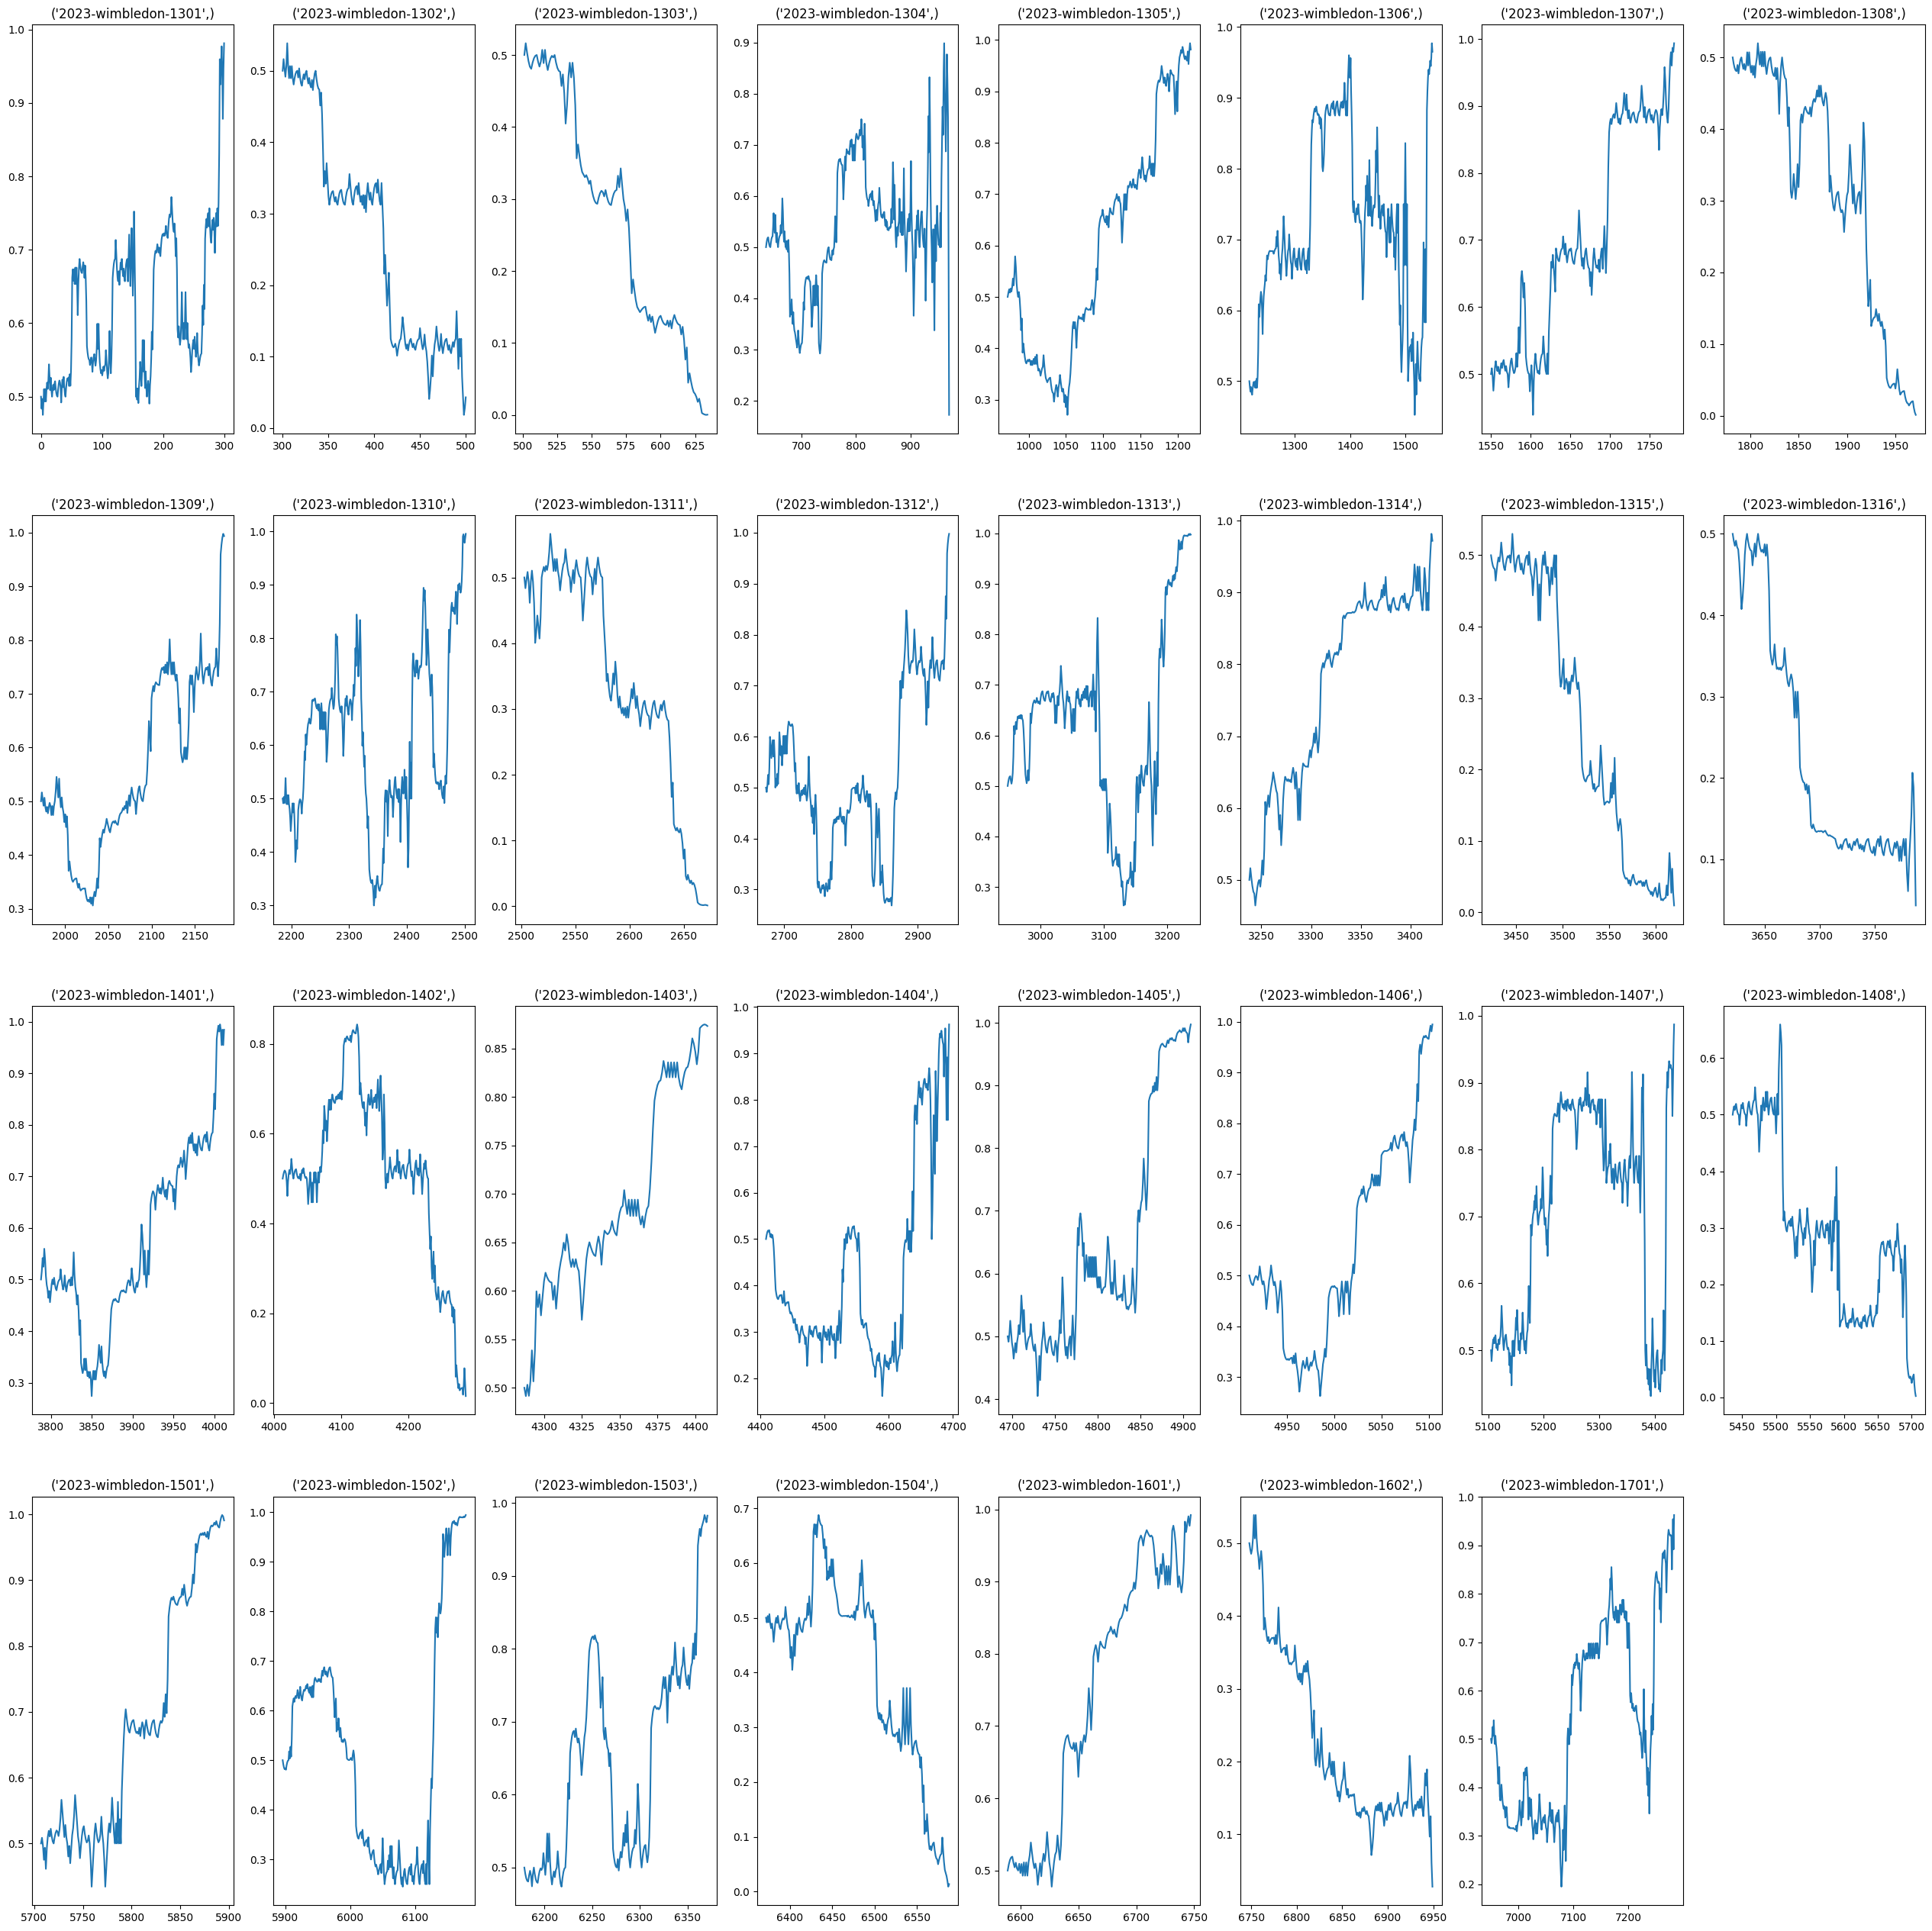

In [6]:
plt.figure(figsize=(32,32))
i = 0
for name, group in df.groupby(['match_id']):
    i += 1
    plt.subplot(4, 8, i)
    plt.plot(group.index, group['aheadness'])
    plt.title(name)

In [190]:
# add derivatives to df
df['win_prob_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'win_prob_dev'] = 0
    else:
        df.loc[i, 'win_prob_dev'] = df.loc[i, 'win_prob'] - df.loc[i-1, 'win_prob']

df['aheadness_dev'] = 0.0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'aheadness_dev'] = 0
    else:
        df.loc[i, 'aheadness_dev'] = df.loc[i, 'aheadness'] - df.loc[i-1, 'aheadness']

for j in [1, 2, 4, 5]:
    df[f'aheadness{j}_dev'] = 0.0
    for i in range(len(df)):
        if df.loc[i, 'point_no'] == 1:
            df.loc[i, f'aheadness{j}_dev'] = 0
        else:
            df.loc[i, f'aheadness{j}_dev'] = df.loc[i, f'aheadness{j}'] - df.loc[i-1, f'aheadness{j}']

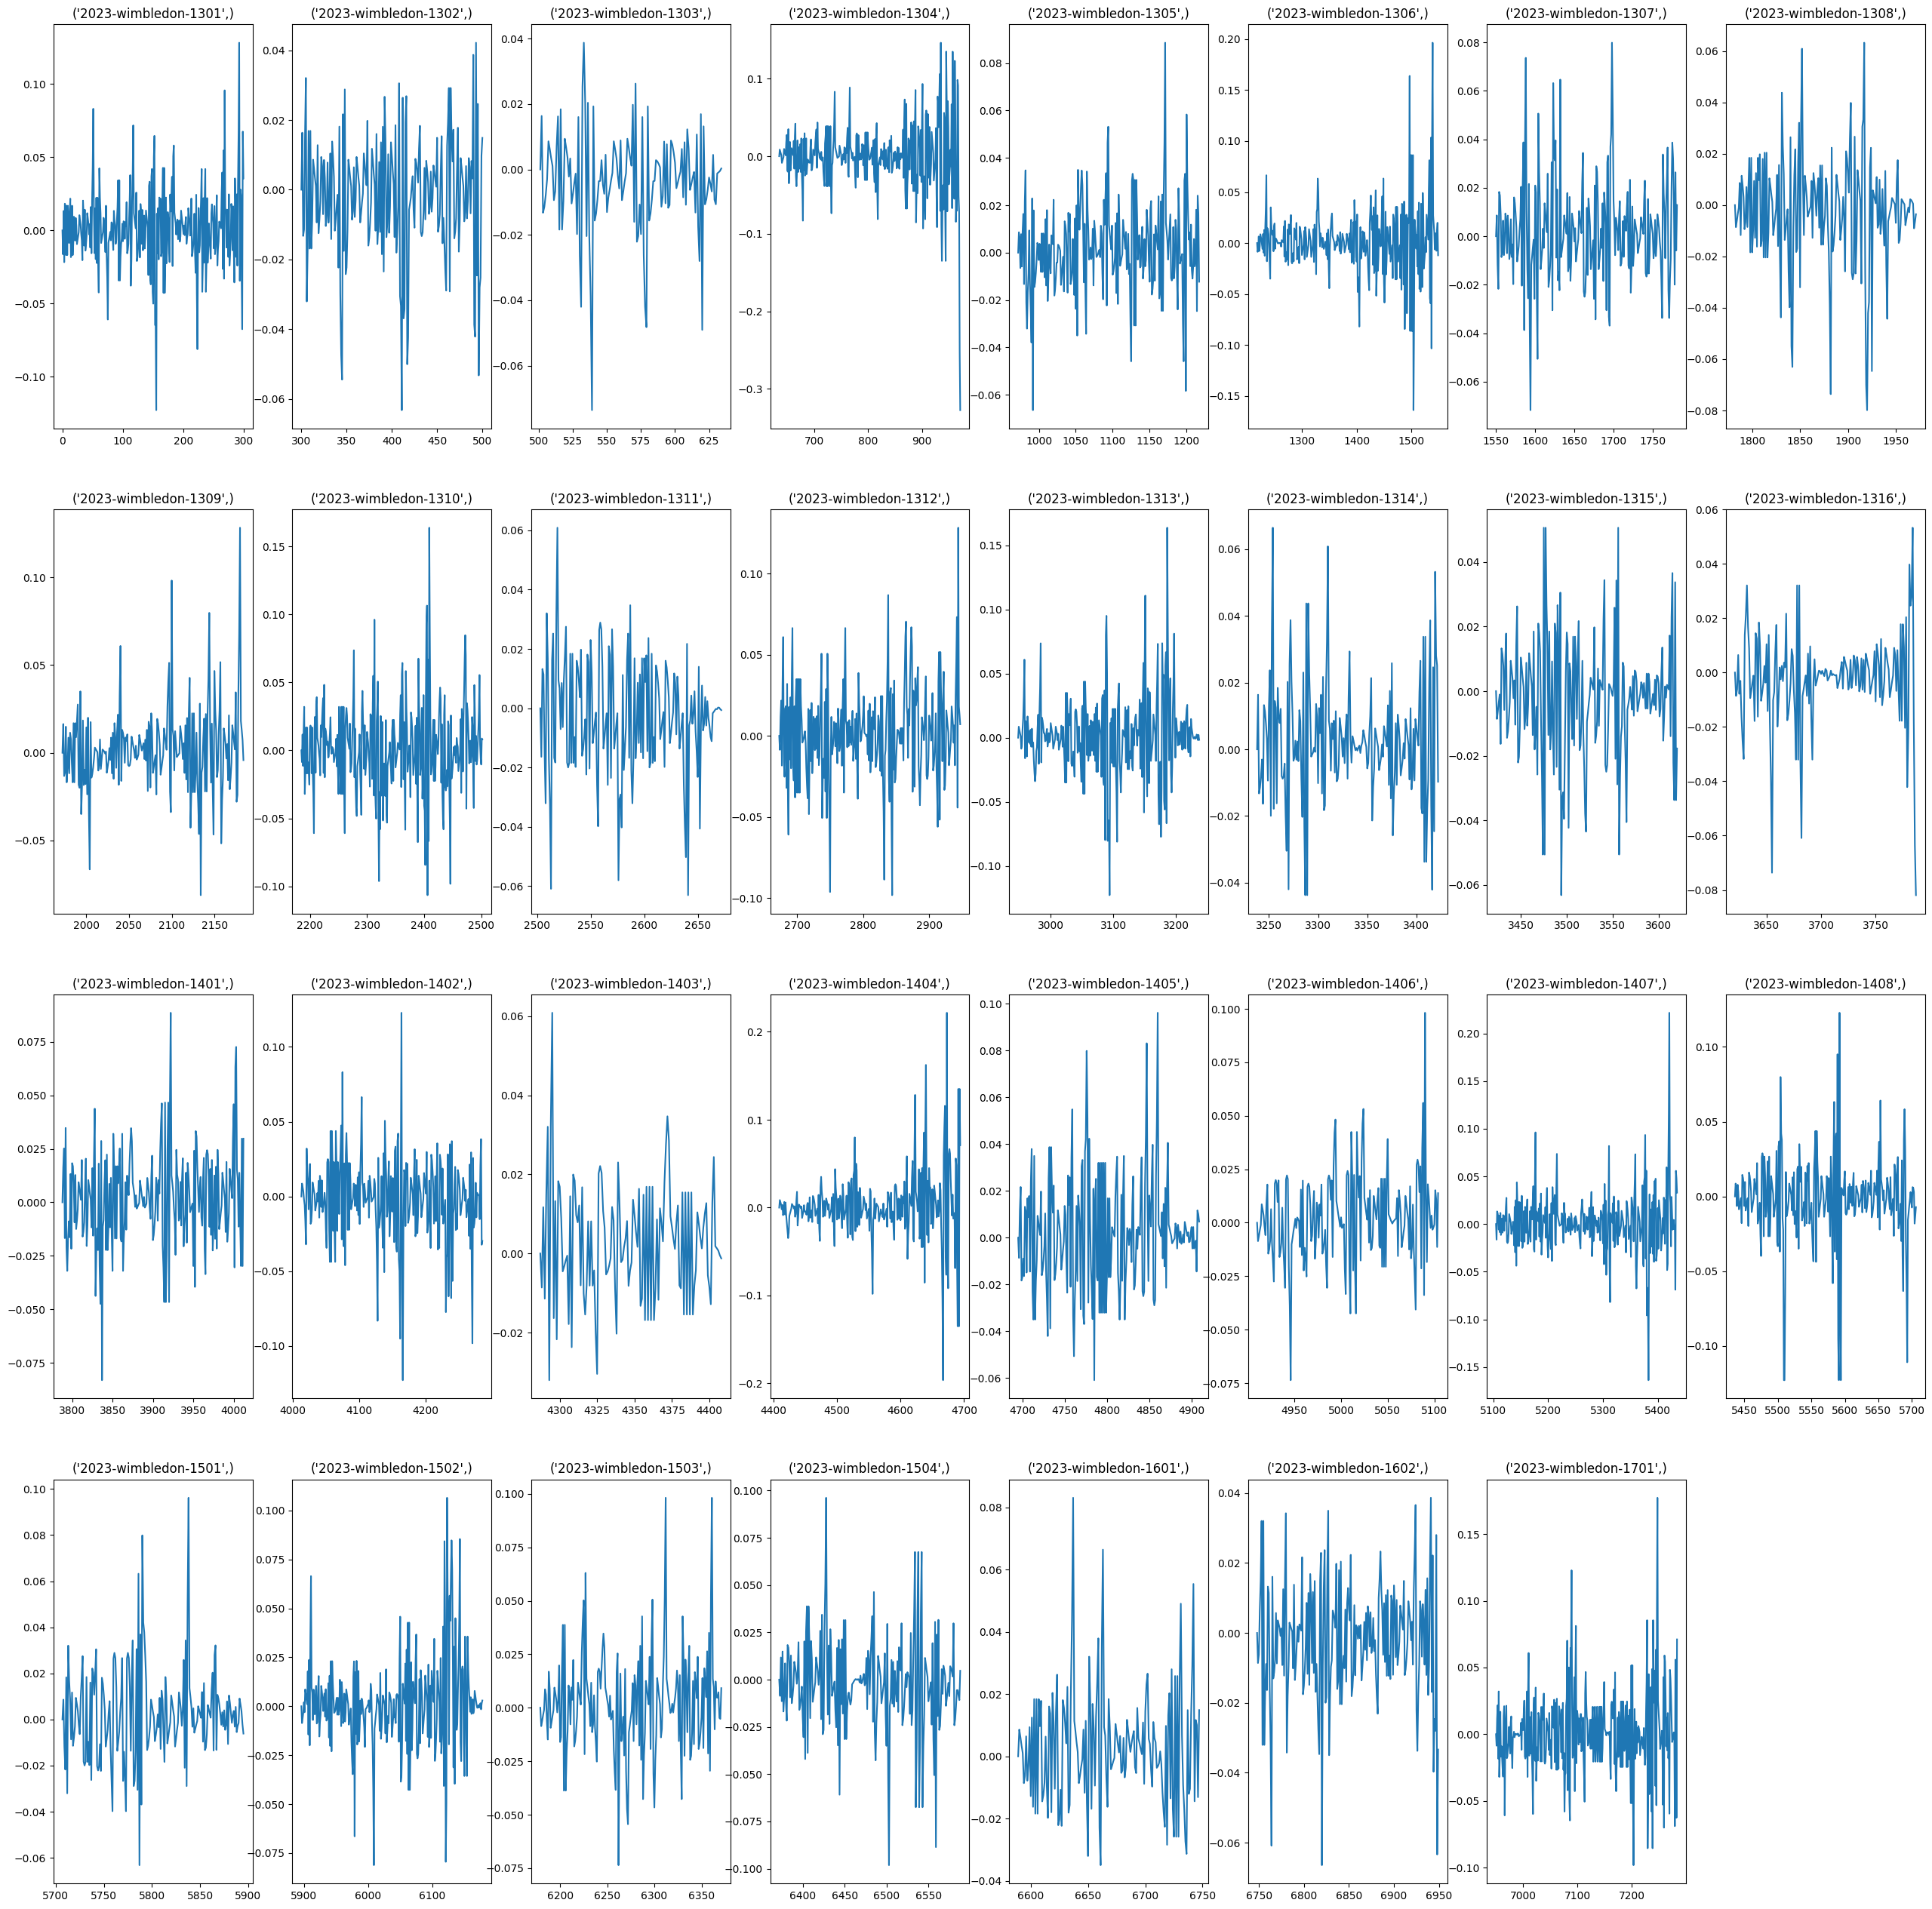

In [31]:
plt.figure(figsize=(32,32))
i = 0
for name, group in df.groupby(['match_id']):
    i += 1
    plt.subplot(4, 8, i)
    plt.plot(group.index, group['aheadness_dev'])
    plt.title(name)

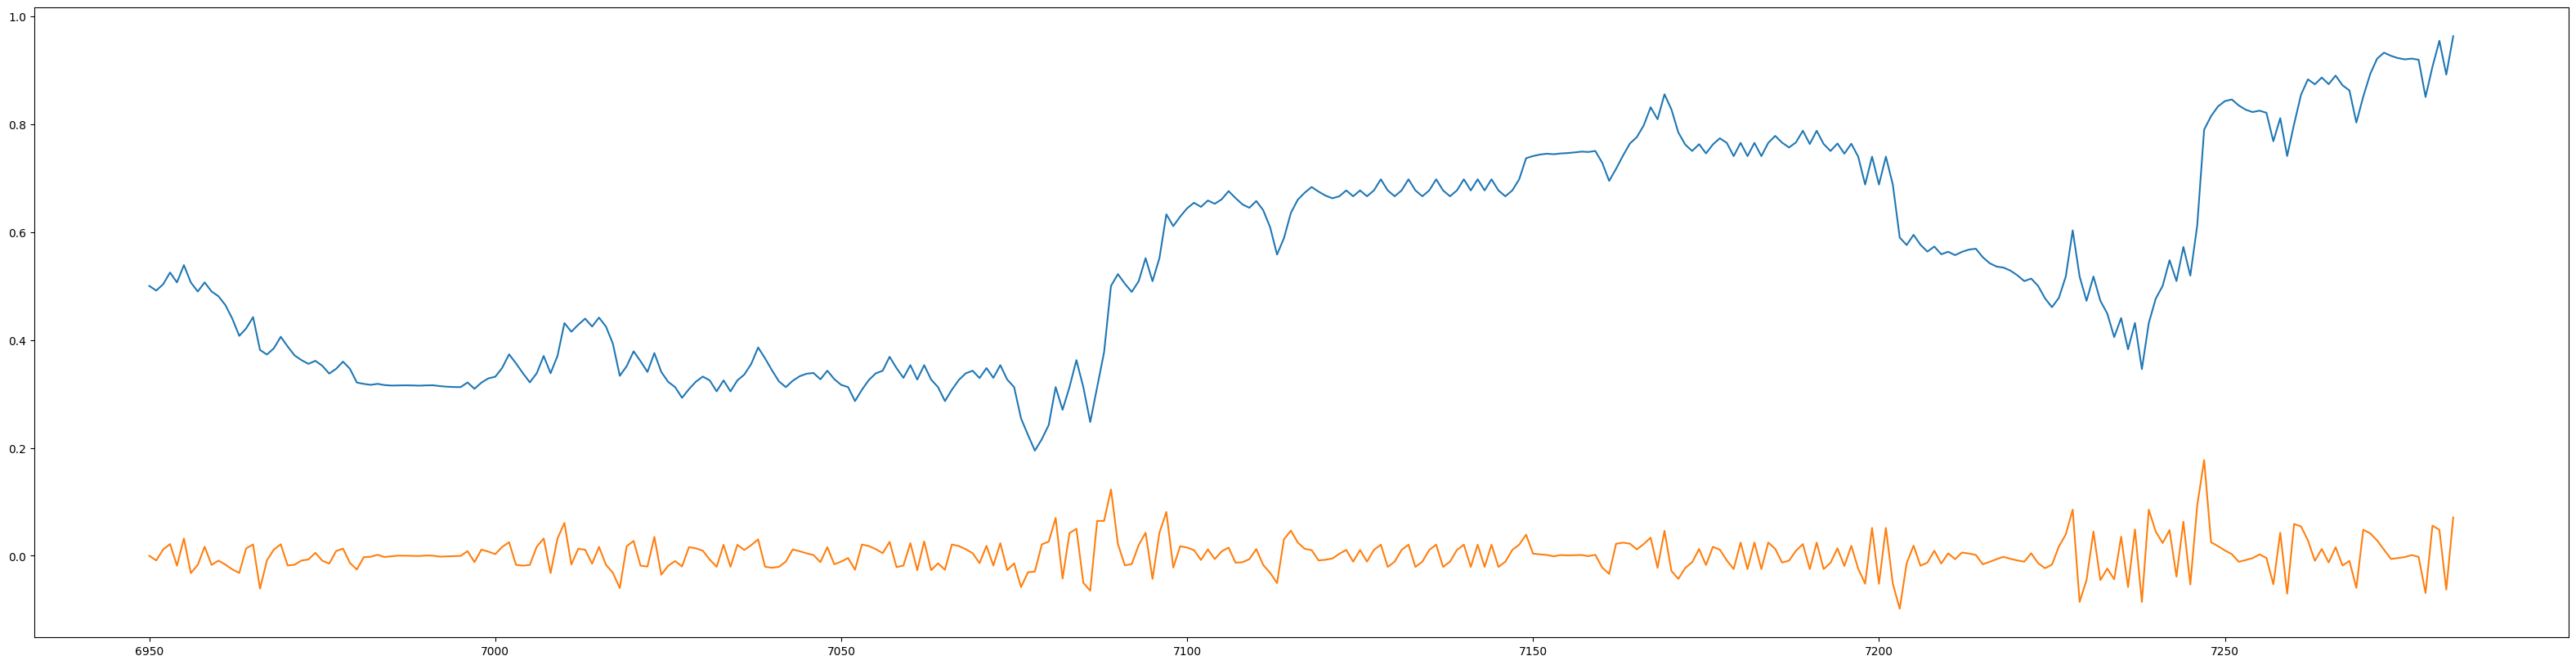

In [42]:
plt.figure(figsize=(40,10))
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness'])
plt.plot(df[df['match_id'] == '2023-wimbledon-1701']['aheadness_dev'])

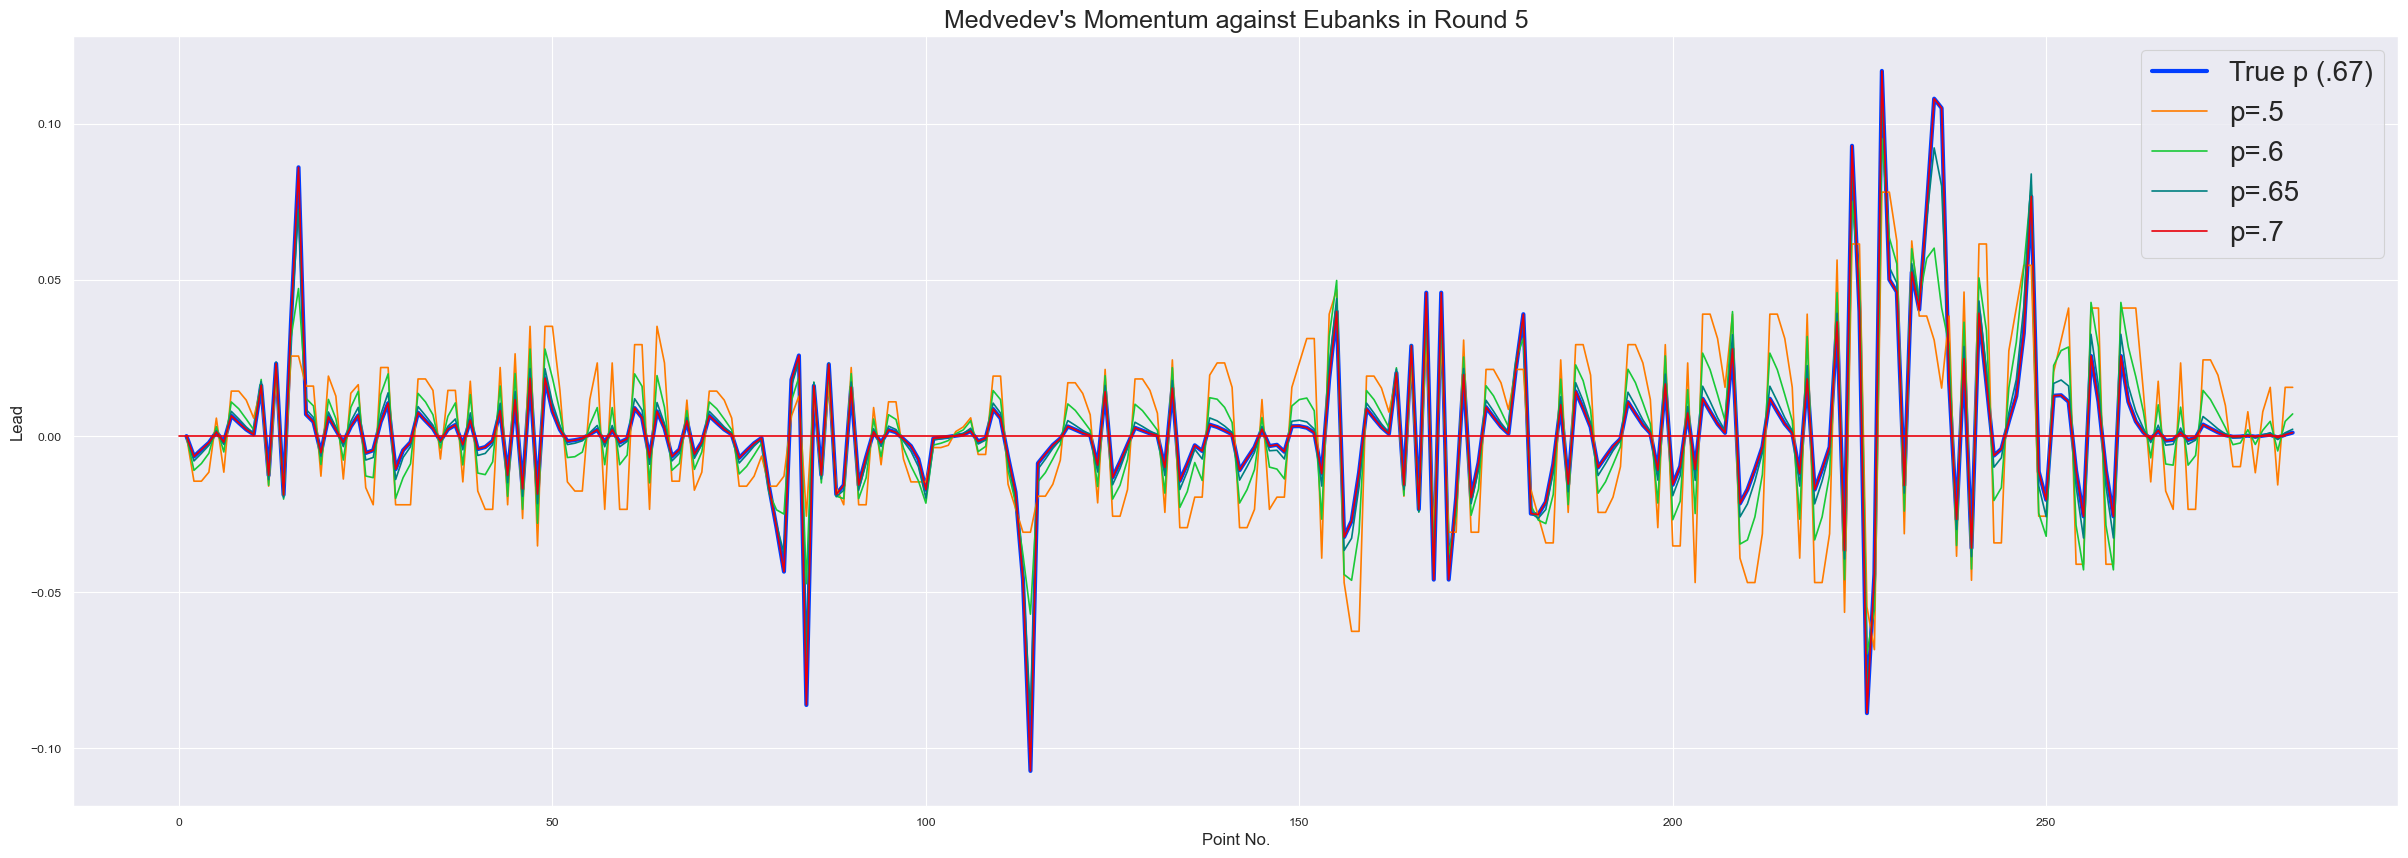

In [201]:
# plt.figure(figsize=(30,10))
# ax = sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness'], linewidth=3, label='True p (.65)')

# sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness1'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness1'], label='p=.5')
# sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness2'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness2'], label='p=.6')
# sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness4'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness4'], label='p=.67')
# sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness5'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness5'], label='p=.7')

# ax.set_xlabel('Point No.', size=12)
# ax.set_ylabel('Lead', size=12)
# ax.set_ylim([0,1])
# ax.set_title("Medvedev's Lead over Eubanks in the Round 5, Match 2", size=18)
# ax.plot([.5 for i in range(1,len(df[df['match_id'] == '2023-wimbledon-1701']['aheadness'])+1)], 'r')
# plt.savefig('1502-aheadness.png')
# ax.legend(fontsize=20)

plt.figure(figsize=(30,10))
ax = sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness_dev'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness_dev'], linewidth=3, label='True p (.67)')

sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness1_dev'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness1_dev'], label='p=.5')
sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness2_dev'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness2_dev'], label='p=.6')
sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness4_dev'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness4_dev'], label='p=.65', color='teal')
sns.lineplot(x=range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness5_dev'])+1), y=df[df['match_id'] == '2023-wimbledon-1502']['aheadness5_dev'], label='p=.7')

ax.set_xlabel('Point No.', size=12)
ax.set_ylabel('Lead', size=12)
# ax.set_ylim([0,1])
ax.set_title("Medvedev's Momentum against Eubanks in Round 5", size=18)
ax.plot([0 for i in range(1,len(df[df['match_id'] == '2023-wimbledon-1502']['aheadness_dev'])+1)], 'r')
plt.savefig('1502-aheadness-dev.png')
ax.legend(fontsize=20)

In [138]:
df['p1_result'] = 0
for i in range(len(df)):
    if df.loc[i, 'point_no'] == 1:
        df.loc[i, 'p1_result'] = -1 if df.loc[i, 'p1_points_won'] == 0 else 1
    else:
        df.loc[i, 'p1_result'] = 1 if df.loc[i, 'p1_points_won'] > df.loc[i-1, 'p1_points_won'] else -1

# k = 4
# df[f'next_{k}'] = 0.0
# for i in range(len(df)-k+1):
#     df[f'next_{k}'] = sum([df.loc[i+j, 'p1_result'] for j in range(k)])

k = 1
df[f'next_{k}'] = 0
for i in range(len(df)-k+1):
    if df.loc[i+k-1, 'match_id'] != df.loc[i, 'match_id']:
        df.loc[i, f'next_{k}'] = np.nan
    else:
        df.loc[i, f'next_{k}'] = sum([df.loc[i+j, 'p1_result'] for j in range(k)])

In [139]:
# bins: 0 if [-inf, -.2], 1 if [-.2,-.1], 2 if [-.1, 0], 3 if [0, .1], 4 if [.1, .2], 5 if [.2, inf]
def bin_aheadness_dev(a):
    if a <= -.2:
        return 0
    elif a <= -.1:
        return 1
    elif a <= 0:
        return 2
    elif a <= .1:
        return 3
    elif a <= .2:
        return 4
    else:
        return 5
df['aheadness_bin'] = df['aheadness_dev'].apply(bin_aheadness_dev)

In [140]:
for name, group in df.groupby('aheadness_bin'):
    print(f"{name}: count {group['aheadness_bin'].count()} : mean outcome of next {k} : {group[f'next_{k}'].mean()}")

0: count 2 : mean outcome of next 1 : -1.0
1: count 18 : mean outcome of next 1 : 0.1111111111111111
2: count 3566 : mean outcome of next 1 : -0.05103757711721817
3: count 3669 : mean outcome of next 1 : 0.08476424093758517
4: count 27 : mean outcome of next 1 : 0.25925925925925924
5: count 2 : mean outcome of next 1 : 0.0


<Axes: xlabel='aheadness_bin', ylabel='next_2'>

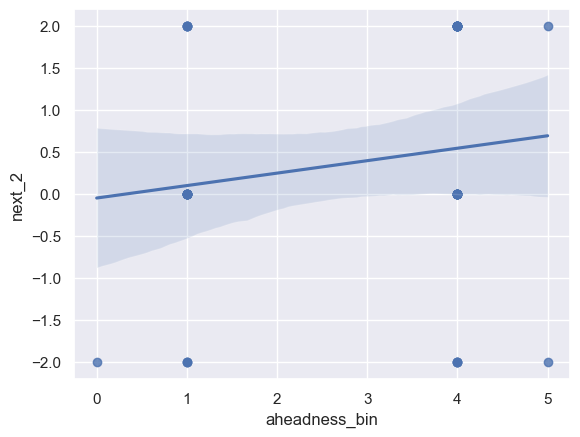

In [130]:
import seaborn as sns
sns.set()
sns.regplot(df[df['aheadness_bin'].isin((4,1,0,5))], x='aheadness_bin', y=f'next_{k}')

In [127]:
strong_aheadness_dev = df[df['aheadness_bin'].isin((4,1,0,5))]
strong_aheadness_dev['aheadness_bin'].corr(strong_aheadness_dev[f'next_{k}'])

0.013197213247511816